# YOLOv11 - Traffic Violation Detection
**Student:** Komal Katare

This notebook includes full implementation of YOLOv11 for detecting traffic violations, including environment setup, dataset preparation, training, inference, and performance evaluation.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyti

100%|██████████| 5.35M/5.35M [00:00<00:00, 102MB/s]


100%|██████████| 49.2k/49.2k [00:00<00:00, 9.26MB/s]


image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 267.1ms
Speed: 12.1ms preprocess, 267.1ms inference, 27.6ms postprocess per image at shape (1, 3, 384, 640)


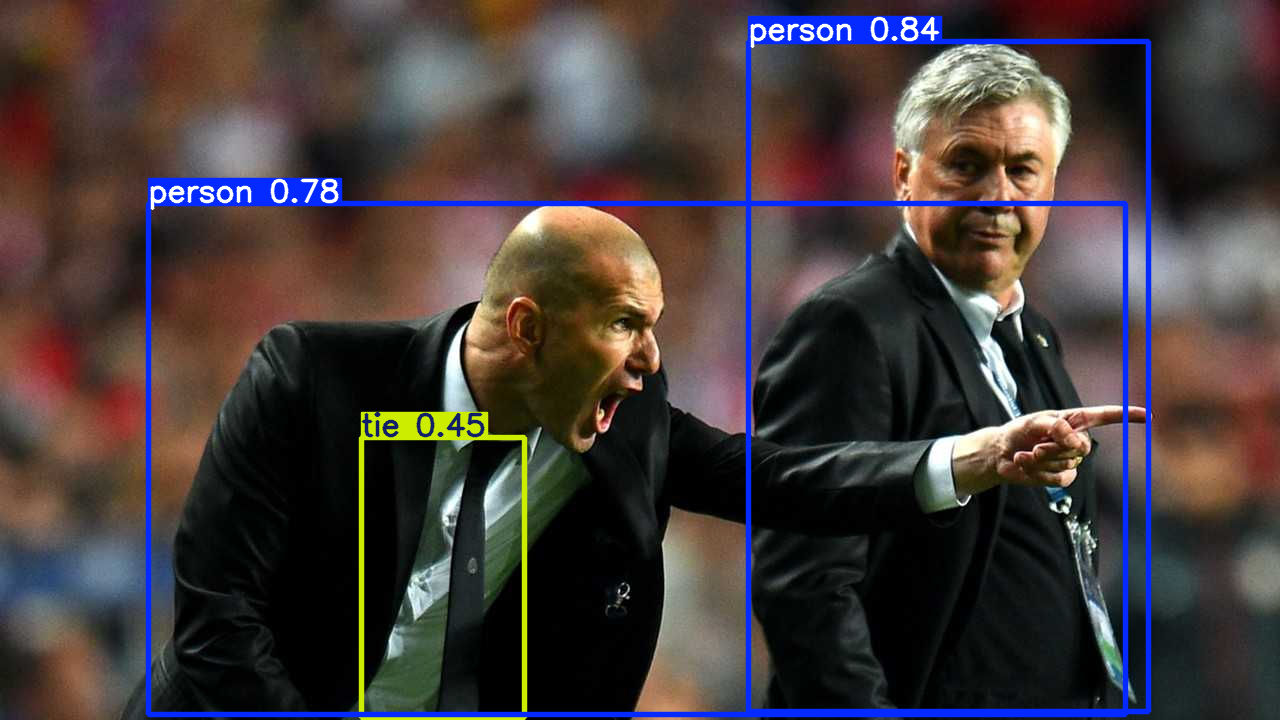

In [1]:
# Task 1: Environment Setup and YOLOv11 Installation
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO('yolo11n.pt')
results = model('https://ultralytics.com/images/zidane.jpg')
results[0].show()


In [3]:
# Task 2: Dataset Preparation
!pip install -q roboflow ultralytics

from roboflow import Roboflow
import os

rf = Roboflow(api_key="jvo1A1u0TUuTM9wD7a3L")
project = rf.workspace("major-project-nlqt0").project("traffic-violation-8voto")
version = project.version(8)
dataset = version.download("yolov11")

dataset_path = "/content/Traffic-violation-8"
yaml_path = os.path.join(dataset_path, "data.yaml")
print("✅ Extracted dataset files:", os.listdir(dataset_path))
print("✅ data.yaml found!" if os.path.exists(yaml_path) else "❌ data.yaml missing!")


loading Roboflow workspace...
loading Roboflow project...
✅ Extracted dataset files: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'train']
✅ data.yaml found!


In [4]:
# Dataset Splitting
import shutil
import random

train_images = os.path.join(dataset_path, "train/images")
train_labels = os.path.join(dataset_path, "train/labels")
valid_images = os.path.join(dataset_path, "valid/images")
valid_labels = os.path.join(dataset_path, "valid/labels")
test_images = os.path.join(dataset_path, "test/images")
test_labels = os.path.join(dataset_path, "test/labels")

os.makedirs(valid_images, exist_ok=True)
os.makedirs(valid_labels, exist_ok=True)
os.makedirs(test_images, exist_ok=True)
os.makedirs(test_labels, exist_ok=True)

all_images = os.listdir(train_images)
random.shuffle(all_images)

valid_split = int(0.1 * len(all_images))
test_split = int(0.1 * len(all_images))

for img in all_images[:valid_split]:
    shutil.move(os.path.join(train_images, img), os.path.join(valid_images, img))
    shutil.move(os.path.join(train_labels, img.replace(".jpg", ".txt")), os.path.join(valid_labels, img.replace(".jpg", ".txt")))

for img in all_images[valid_split:valid_split + test_split]:
    shutil.move(os.path.join(train_images, img), os.path.join(test_images, img))
    shutil.move(os.path.join(train_labels, img.replace(".jpg", ".txt")), os.path.join(test_labels, img.replace(".jpg", ".txt")))

print("✅ Dataset split completed!")


✅ Dataset split completed!


In [5]:
# Update YAML paths
import yaml

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["train"] = train_images
data["val"] = valid_images
data["test"] = test_images

with open(yaml_path, "w") as f:
    yaml.dump(data, f)

print("✅ data.yaml updated successfully!")


✅ data.yaml updated successfully!


In [6]:
# Task 3: Train YOLOv11
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
results = model.train(
    data=yaml_path,
    epochs=5,
    batch=8,
    device="cpu"
)

model.export(format="onnx")


Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Traffic-violation-8/data.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_

100%|██████████| 755k/755k [00:00<00:00, 19.4MB/s]

Overriding model.yaml nc=80 with nc=12

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytic

YOLO11n summary: 181 layers, 2,592,180 parameters, 2,592,164 gradients, 6.5 GFLOPs

Transferred 448/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1648.3±836.2 MB/s, size: 366.7 KB)


train: Scanning /content/Traffic-violation-8/train/labels... 648 images, 0 backgrounds, 0 corrupt: 100%|██████████| 648/648 [00:00<00:00, 1939.27it/s]

...

                   all         80        783      0.669      0.571      0.558      0.451



5 epochs completed in 0.753 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,584,492 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:19<00:00,  3.97s/it]


                   all         80        783       0.67       0.57      0.557      0.451
          Auto Rikshaw         22         56      0.565      0.821      0.783      0.707
                   Bus         20         30      0.827      0.967      0.953      0.914
                   Car         26         80       0.69      0.887      0.897       0.82
                Helmet         43        134      0.383      0.254      0.201     0.0855
            Motorcycle         68        188       0.76      0.936      0.944      0.677
             No_Helmet         30         95      0.241     0.0632      0.102     0.0286
                 Rider         45        117      0.624      0.786      0.758      0.541
         Triple Riding         45         45      0.851      0.911       0.89      0.663
                 Truck         13         24      0.262       0.25      0.183      0.152
                mobile          2          2          1          0          0          0
                 stun

'runs/detect/train/weights/best.onnx'

Loading runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime CPUExecutionProvider

image 1/1 /content/Traffic-violation-8/test/images/overload-303-_jpg.rf.31ebc5f55c32097c27ce061ba911b864.jpg: 640x640 2 Helmets, 1 Motorcycle, 1 Rider, 1 Triple Riding, 202.6ms
Speed: 25.3ms preprocess, 202.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


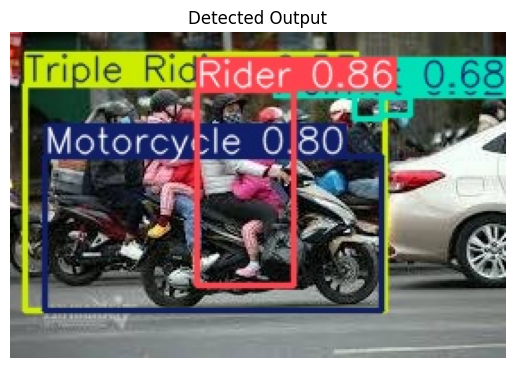

In [7]:
# Task 4: Inference
import cv2
import matplotlib.pyplot as plt
import glob

model = YOLO("runs/detect/train/weights/best.onnx")
image_path = glob.glob(os.path.join(test_images, "*.jpg"))[0]
results = model(image_path, save=True, conf=0.5)

detect_folders = sorted(glob.glob("runs/detect/predict*"), key=os.path.getmtime, reverse=True)
save_dir = detect_folders[0] if detect_folders else "runs/detect/predict"
detected_image_path = glob.glob(f"{save_dir}/*.jpg")[0]

img = cv2.imread(detected_image_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Output")
plt.show()


In [8]:
# Evaluate Model
import numpy as np
import seaborn as sns

metrics = model.val(data=yaml_path)
map_50 = metrics.box.map50
map_50_95 = metrics.box.map
precision = metrics.box.p.mean()
recall = metrics.box.r.mean()
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"✅ mAP@50: {map_50:.4f}")
print(f"✅ mAP@50-95: {map_50_95:.4f}")
print(f"✅ Precision: {precision:.4f}")
print(f"✅ Recall: {recall:.4f}")
print(f"✅ F1 Score: {f1_score:.4f}")


Ultralytics 8.3.123 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Loading runs/detect/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1265.3±703.9 MB/s, size: 488.9 KB)


val: Scanning /content/Traffic-violation-8/valid/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100%|██████████| 80/80 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 80/80 [00:15<00:00,  5.13it/s]


                   all         80        783      0.677       0.58      0.558      0.451
          Auto Rikshaw         22         56      0.569      0.839      0.779       0.69
                   Bus         20         30      0.864      0.967      0.954       0.91
                   Car         26         80      0.691      0.887      0.907      0.818
                Helmet         43        134      0.384      0.276      0.203     0.0925
            Motorcycle         68        188      0.719      0.931      0.942      0.677
             No_Helmet         30         95      0.314      0.105     0.0991     0.0291
                 Rider         45        117       0.62      0.824      0.764      0.532
         Triple Riding         45         45      0.859      0.911      0.905      0.668
                 Truck         13         24      0.269      0.292       0.17      0.142
                mobile          2          2          1          0          0          0
                 stun

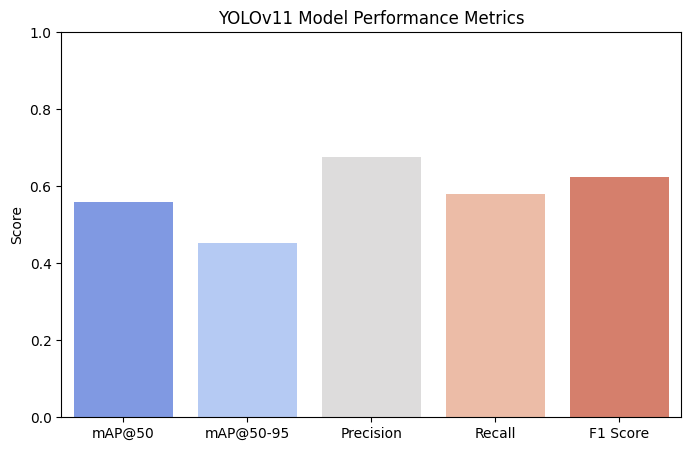

In [9]:
# Plot Bar Chart
metrics_labels = ["mAP@50", "mAP@50-95", "Precision", "Recall", "F1 Score"]
metrics_values = [map_50, map_50_95, precision, recall, f1_score]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics_labels, y=metrics_values, palette="coolwarm")
plt.title("YOLOv11 Model Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


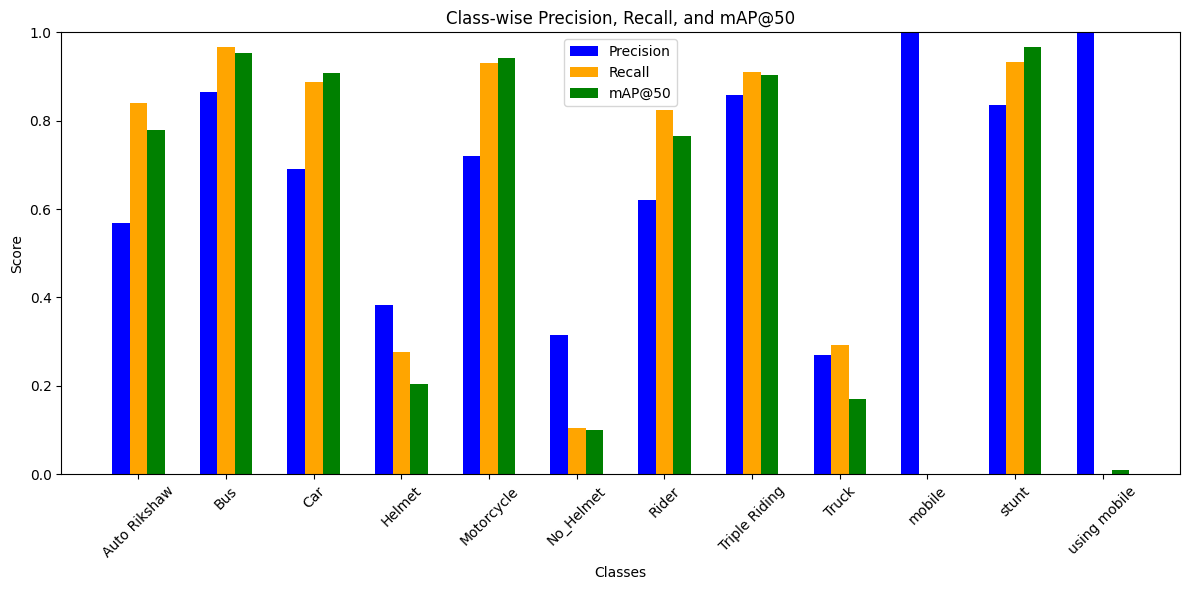

In [10]:
# Class-wise Performance
class_names = list(metrics.names.values())
x = np.arange(len(class_names))
class_precision = np.array(metrics.box.p)
class_recall = np.array(metrics.box.r)
class_map50 = np.array(metrics.box.ap50)

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, class_precision, 0.2, label="Precision", color='blue')
plt.bar(x, class_recall, 0.2, label="Recall", color='orange')
plt.bar(x + 0.2, class_map50, 0.2, label="mAP@50", color='green')
plt.xticks(ticks=x, labels=class_names, rotation=45)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Class-wise Precision, Recall, and mAP@50")
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
